# STAT 207 Project 03 - What Makes Video Games Successful?

Connor Quadrini, Akshit Makkar
<hr>

Connor Quadrini completed parts 1 & 2

Akshit Makkar completed parts 3 & 4

We both reviewed the full document before submission.

## 1. Introduction

We chose to analyze a dataset about the sales of videogames from 2004 - 2010; it was originally used to explore the question: 'what makes a blockbuster game?' Observations in the datset include year released, the console it's on, US sales, Review Score, and publisher of each video game (to name a few). We decided to use this dataset because it was easy to access and me and my partner both play and are interested in video games. The research question we intend to answer are: What factors create successful video games? (This summarizes both research questions asked later) The response variable used will be US sales for both respective models. Someone would be interested in answering these questions because they provide insight to what causes games to be popular or successful; An example where someone would use the answer to this research question would be for a video game developer deciding which console to release their game on.

In [39]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, roc_auc_score, confusion_matrix, accuracy_score
import seaborn as sns; sns.set()

In [18]:
dfb = pd.read_csv("video_games.csv", encoding = "unicode-escape")
df = dfb.copy()
df = df.drop(columns = ["2004", "2005", "2006", "2007", "2008", "2009", "2010", "Action", "Sports", "Strategy", "RPG", "Racing", "Simulation"])
df = df.rename(columns = {'US Sales (millions)': 'US_Sales_millions', 'Review Score': 'Review_Score'})
df

,Console,Title,US_Sales_millions,Block4,Block2,Block1,Block0.5,YearReleased,YearReleasedSq,Publisher,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,4016016,"Nintendo Australia Pty., Ltd., Nintendo Co., L...",...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,4016016,"Bandai Co., Ltd., Ubisoft Entertainment SA, Ub...",...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,4016016,"Nintendo Australia Pty., Ltd., Nintendo Co., L...",...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,4016016,"Sony Computer Entertainment America, Inc., SCE...",...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,4016016,"Activision Asia-Pacific, Activision Deutschlan...",...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1765,PlayStation 3,MotoGP 09/10,0.04,0,0,0,0,2010,4040100,CE Europe Ltd.,...,0,0,0,0,1,0,0,0,0,1
1766,PlayStation 3,Prison Break: The Conspiracy,0.04,0,0,0,0,2010,4040100,"Deep Silver, Inc.",...,0,0,0,0,0,0,0,0,0,1
1767,Nintendo Wii,"Sakura Wars: So Long, My Love",0.04,0,0,0,0,2010,4040100,"NIS America, Inc.",...,0,0,0,0,0,0,0,0,0,1
1768,X360,Record of Agarest War (The Really Naughty Limi...,0.04,0,0,0,0,2010,4040100,Aksys Games,...,0,0,0,0,0,0,1,0,0,0


## 2. Linear Regression Analytical Tasks

What factors create popular games? --> What is the relationship between review score and US sales after controlling for console, year released, and publisher both in the sample and in the underlying population? How does this model perform on new data?

In [19]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=592)

In [25]:
model = smf.ols('US_Sales_millions ~ Console + YearReleased + Review_Score + Multiplatform', data = df_train).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      US_Sales_millions   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     26.04
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.10e-33
Time:                        21:20:14   Log-Likelihood:                -2069.8
No. Observations:                1416   AIC:                             4156.
Df Residuals:                    1408   BIC:                             4198.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   83.2330     46.599      1.786      0.074      -8.177     174.643
Console[T.Nintendo Wii]      0.3225      0.092      3.501      0.000       0.142       0.503
Console[T.PlayStation 3]    -0.1033      0.097     -1.067      0.286      -0.293       0.087
Console[T.Sony PSP]         -0.2890      0.089     -3.235      0.001      -0.464      -0.114
Console[T.X360]              0.0532      0.087      0.611      0.542      -0.118       0.224
YearReleased                -0.0421      0.023     -1.811      0.070      -0.088       0.003
Review_Score                 0.0251      0.002     12.315      0.000       0.021       0.029
Multiplatform               -0.0412      0.060     -0.690      0.490      -0.158       0.076
==============================================================================
Omnibus:                     1874.350   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           309831.784
Skew:                           7.273   Prob(JB):                         0.00
Kurtosis:                      73.992   Cond. No.                     3.37e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.37e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Linear regression equation for a game on the Playstation 3:
y = 83.2330 - 0.1033 - 0.0421(Year Released) + 0.0251(Review Score) - 0.0412(Multiplatform)
y = 83.1297 - 0.0421(Year Released) + 0.0251(Review Score) - 0.0412(Multiplatform)

For Review Score, there is a positive slope of 0.0251, which means for every point increase in the observed review score, there is a 0.0251 million dollar increse in US Sales when holding console, year released, and multiplatform constant. It's important to note that this is a correlation, and does not show causation.

95% Confidence Interval:
(0.0251 - 1.96(0.002), 0.0251 + 1.96(0.002))
(0.02118, 0.02902)
The p value is 0.000... on the model summary, so it's very significant as it is much less than the significance level of 0.05. Thus, I would infer that with each one point increase in review score, the sales of a game increase by a quantity bewteen 0.02118 and 0.02902 million dollars.

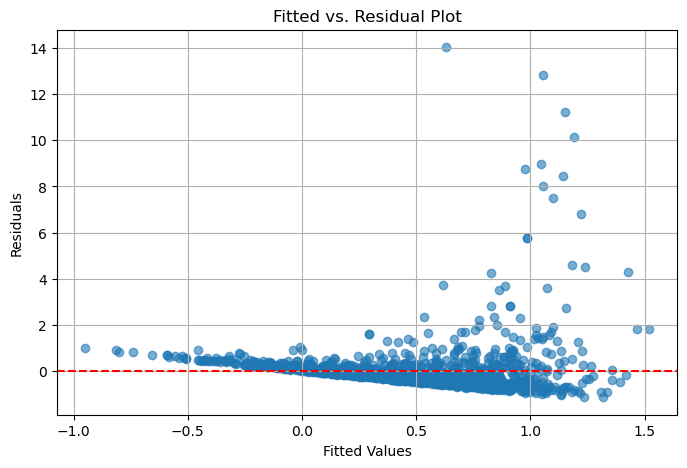

In [29]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Fitted vs. Residual Plot')
plt.grid(True)
plt.show()


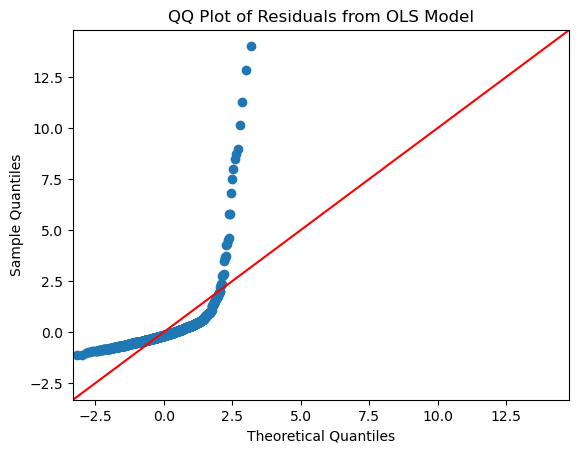

In [32]:
sm.qqplot(model.resid, line = '45')
plt.title('QQ Plot of Residuals from OLS Model')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()


Assessing the fitted vs residuals graph, the points are not randomly/evenly spread across the range of fitted values. Now looking at the Q-Q plot, the points do not stay close to the 45 degree line. With this in mind, neither of the graphs support the inference made earlier becuase they both show that the model is weak, as the conditions for regression are not met. 

The R^2 value for the model is 0.115, meaning 11.5% of the variability in US sales is explained by this model (using the training data). This is low, as 88.5% of the variability is caused by other factors not accounted for in the model.

In [37]:
rmse_test = np.sqrt(np.mean(smf.ols('US_Sales_millions ~ Console + YearReleased + Review_Score + Multiplatform', data = df_test).fit().resid**2))
rmse_test, df["US_Sales_millions"].mean()

(np.float64(0.7890617948836669), np.float64(0.47978531073446323))

The RMSE of the test data is 0.78906, which is larger than the average US sales of video games in the data, so this value is very high. What this value means is that on average, the models prediction is off by about 0.789 million dollars when predicting the price of a video game.

## 3. Logistic Regression Analytical Tasks

To what extent does a game’s console type (handheld or not), review score, and licensing status relate to the log-odds that a game becomes a commercial success in the training data? Additionally, how accurately can a classifier built from this logistic-regression model predict commercial success in new test data?

In [51]:
dfn = dfb.copy()
dfn["Success"] = (dfn["US Sales (millions)"] > 1).astype(int)
X = dfn[["Handheld", "Review Score", "Licensed"]]
y = dfn["Success"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=592)

X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.253848
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Success   No. Observations:                 1416
Model:                          Logit   Df Residuals:                     1412
Method:                           MLE   Df Model:                            3
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2488
Time:                        23:06:42   Log-Likelihood:                -359.45
converged:                       True   LL-Null:                       -478.50
Covariance Type:            nonrobust   LLR p-value:                 2.444e-51
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.0171      1.009    -11.910      0.000     -13.995     -10.040
Handheld        -0.4651      0.216     -2.149      0.032      -0.889      -0.041
Review Score     0.1340      0.012     10.959      0.000       0.110       0.158
Licensed        -0.3908      0.231     -1.691      0.091      -0.844       0.062
================================================================================
"""

**What characteristics are associated with higher probability of success?**

Review score - a higher review score would lead to a higher  probability of success as the coefficient is 0.1340 which is positive and significant.

Handheld - if the gaming console is a handheld the probability of commercial success is lower as indicated by the negative and significant coefficient -0.4651

Licensed - the probability of commercial success is lower as indicated by the negative and significant coefficient -0.3908 

The pseudo-R^2 is 0.2488, which indicates that about 24.88% of variation in log-odds of success is accounted for by the model. The AUC is 0.7830, which indicates the strength of the model, and it's strong since its over 0.7.


In [52]:
X_test_sm = sm.add_constant(X_test)
Y_prob = logit_model.predict(X_test_sm)
auc = roc_auc_score(y_test, Y_prob)
auc


0.783064287737185

In [54]:
threshold = 0.5
Y_pred = (Y_prob >= threshold).astype(int)

In [55]:
cm = confusion_matrix(y_test, Y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, Y_pred)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
cm, accuracy, sensitivity, specificity


(array([[319,   2],
        [ 24,   9]]),
 0.9265536723163842,
 np.float64(0.2727272727272727),
 np.float64(0.9937694704049844))

We should attempt to minimize a false negative, which is when we predict that an outcome will not occur but it actually does. In this context, a false negative error would be that we predict that a game will not achieve commercial success but it actually does (making us miss out on profit).

I am not satisfied with the performance of my current classifier because we want to avoid false negatives. To add, our sensitivity is 0.2727 which is very low -- this means it frequently missed successful games,

## 4. Conclusion

For the linear regression task, the model showed a positive/direct correlation between US sales and review score, and games made for the wii and Xbox360. Unfortunately, the model did not display strong reliability or strength as shown in the Q-Q or fitted vs residual plots. The RMSE was very high compared to the average US sales in the dataset, and explained a low amount of variation (11.5%).

For the logistic regression task, the model showed that review score strongly increases the probability of commercial success, while handheld console type and licensing status slightly decreases it. The model explained a moderate amount of variation (23%) and demonstrated strong predictive ability with an AUC of 0.78. Although the classifier achieved high accuracy, its very low sensitivity means it frequently missed successful games, which isn't for situations where avoiding false negatives is important and that's what we were prioritizing since its the most costly error.

The main limitation we faced in our analysis/interpretations is that this dataset is a model for games from 2004-2010, which is pretty old and the gaming industry has changed a lot by now. Therefore, we couldn't really generalize our interpretations into real time due to new consoles coming out, new player bases, etc. Some challenges we faced were selecting our variables for our research questions, as variables like a budget for the game or how popular this type of game is weren't present but these types of variables are very important for determining commercial success. Based on the context and limitations of this dataset, a video game developer deciding what console to make their game on should probably not make their decision solely based on our research and models.

If future work were to be conducted based on this report, we could improve on our models by getting more data on variables more related to our research questions such as budgets, status of the brand, etc. With more data, we could answer new research questions like if the game is made by a certain company the probability of commercial success rises. This expanded analysis would allow for a more accurate and comprehensive model that better captures the real drivers of success in the video game market.
